In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/isaikumar/creditcardfraud/creditcard.csv


## 1.  IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. LOAD THE DATASET

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/isaikumar/creditcardfraud/creditcard.csv')



## Insight

This dataset contains credit card transactions made by European cardholders.
It includes **284,807 transactions**, of which **492 are fraudulent.**

The dataset is **highly imbalanced**, with fraud transactions representing only **0.17%** of all transactions.

The features **V1–V28** are anonymized variables created using **PCA transformation** to protect sensitive information.

The **Class** column indicates whether a transaction is fraudulent:

**0 → Normal transaction**

**1 → Fraud transaction**

## 3. VIEW FIRST 5 ROWS

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. CHECK DATASET SHAPE

In [5]:
df.shape

(284807, 31)

## 5. CHECK COULUMN INFORMATION

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28


## Insight

The dataset contains **284,807 transactions across 31 columns**, including anonymized transaction features **(V1–V28)**, transaction time, and transaction amount. All variables have **284,807 non-null values**, indicating **there are no missing values in the dataset**. Most features are stored as **float64**, while the target variable **Class** is an integer indicating whether a transaction is **fraudulent (1) or normal (0)**. This confirms that the dataset is **clean and suitable for further analysis and model development.**

## 6. STATISTICAL SUMMARY  

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Insight**

The statistical summary provides an overview of the dataset’s numerical features, including measures such as **mean, standard deviation, and quartiles**. All variables contain **284,807 observations**, indicating that **there are no missing values in the dataset**. The anonymized variables **(V1–V28)** appear to be standardized features generated through **PCA transformation**, which helps preserve sensitive financial information while still enabling effective fraud detection analysis.
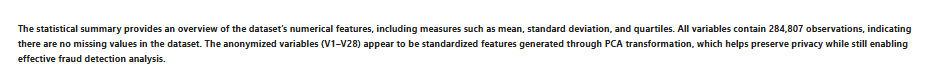

## 7. CHECK FRAUD VS NORMAL TRANSACTIONS

In [8]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### Insight

The dataset is **highly imbalanced**, with fraudulent transactions representing only **0.17% of all transactions**. This extreme imbalance makes fraud detection challenging for machine learning models and requires techniques such as **SMOTE and advanced classifiers** to improve detection performance.

## 8. VISUALISE FRAUD DISTRIBUTION

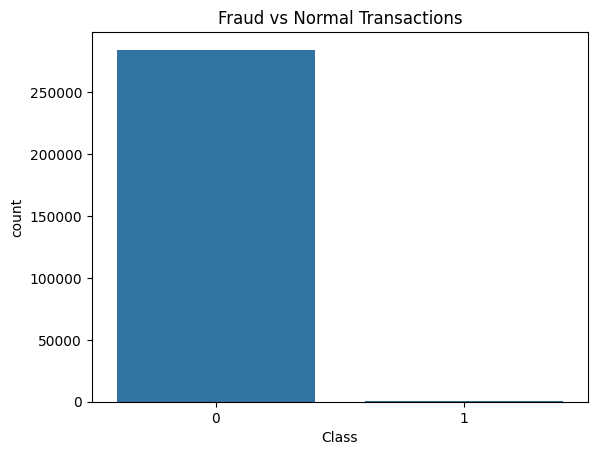

In [9]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

### Insight

The visualization shows a **significant imbalance** between normal and fraudulent transactions. The majority of transactions belong to the **normal class**, while fraudulent transactions represent only a **very small portion of the dataset**. This imbalance highlights the challenge of fraud detection and emphasizes the importance of using techniques such as **resampling methods and advanced machine learning models**.

## 9. FRAUD PERCENTAGE

In [10]:
fraud = df['Class'].value_counts()[1]
total = len(df)

print("Fraud Percentage:", (fraud/total)*100)

Fraud Percentage: 0.1727485630620034


### Insight

The fraud percentage in the dataset is approximately **0.17%**, indicating that fraudulent transactions are **extremely rare** compared to normal transactions. This severe class imbalance makes fraud detection challenging and highlights the need for techniques such as **SMOTE** and **advanced machine learning models** to improve fraud detection performance.

## 10. ANALYSE TRANSACTION AMOUNT

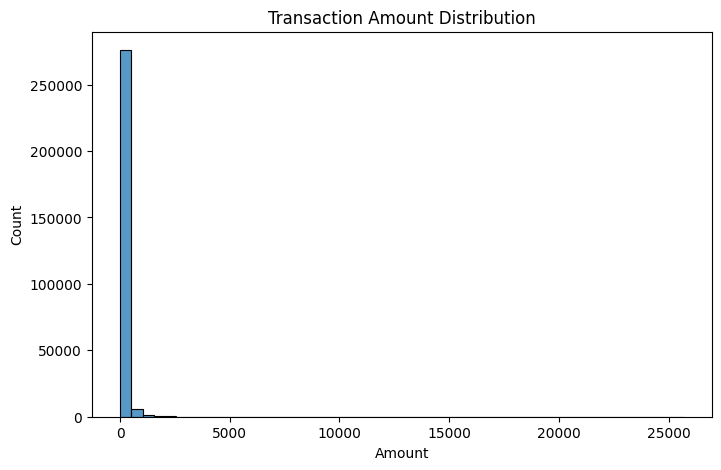

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

### Insight

The transaction amount distribution is **highly right-skewed**, with most transactions occurring at small values while only a few involve large amounts. This suggests that typical credit card activity consists of low-value purchases, while high-value transactions are relatively rare and may require additional monitoring for potential fraud.

## 11. COMPARE FRAUD VS NORMAL AMOUNT

In [12]:
fraud_df = df[df['Class']==1]
normal_df = df[df['Class']==0]

print("Fraud Amount Mean:", fraud_df['Amount'].mean())
print("Normal Amount Mean:", normal_df['Amount'].mean())

Fraud Amount Mean: 122.21132113821139
Normal Amount Mean: 88.29102242231328


### Insight

The comparison indicates that the **average transaction amount for fraudulent transactions is higher than that of normal transactions**. This suggests that fraudulent activities may involve **slightly larger transaction values**, which can act as a potential indicator of suspicious behavior.

## 12. PREPARE DATA FOR MACHINE LEARNING

In [13]:
X = df.drop('Class', axis=1)
y = df['Class']

### Insight

In this step, the dataset is separated into **input features (X)** and the **target variable (y)**. The feature set contains all transaction-related variables, while the target variable indicates whether a transaction is **fraudulent (1)** or **normal (0)**. This separation is essential for training machine learning models to learn patterns that distinguish fraudulent transactions from legitimate ones.


## 13. SPLIT DATA

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Insight

The dataset is divided into **training and testing sets**, allowing the model to learn patterns from the training data and evaluate its performance on **unseen test data**. This approach helps measure how well the model generalizes to new transactions.

## 14. TRAIN FRAUD DETECTION MODEL

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

### Insight

In this step, a **Logistic Regression model** is trained using the **training dataset**. Logistic Regression is a widely used **binary classification algorithm**, making it suitable for problems such as **fraud detection**. The model learns patterns in transaction features to distinguish between **fraudulent (1)** and **normal (0)** transactions.

## 15. MAKE PREDICTION

In [16]:
y_pred = model.predict(X_test)

### Insight

The trained **Logistic Regression model** is used to predict whether transactions in the **test dataset** are fraudulent or normal. These predictions help evaluate the model’s ability to **generalize to unseen transaction data** and measure its fraud detection performance.

## 16. EVALUATE MODEL

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.57      0.69        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



### Insight

The model achieved an overall **accuracy of approximately 99%** on the test dataset. It correctly classified **56,864 normal transactions** with almost perfect precision and recall. For fraudulent transactions, the model correctly detected **56 out of 98 fraud cases**, achieving a **precision of 0.86** and a **recall of 0.57**. This means the model detected about **57% of fraudulent transactions**, while some fraud cases were still missed due to the **severe class imbalance in the dataset**.

## 17. CONFUSION MATRIX

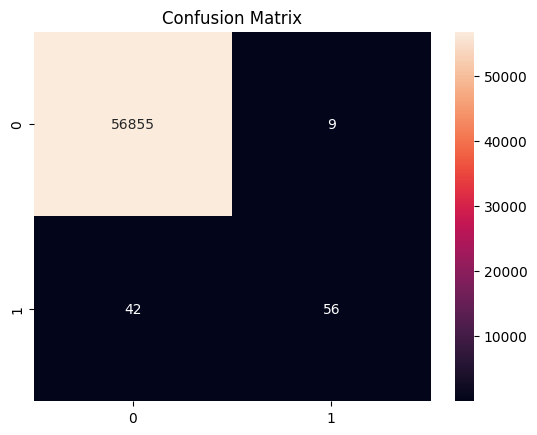

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Insight

The confusion matrix shows that the model correctly classified **56,855 normal transactions**, while incorrectly flagging **9 normal transactions as fraud**. For fraudulent transactions, the model successfully detected **56 fraud cases** but failed to identify **42 fraud transactions**.

This indicates that while the model performs very well in identifying **normal transactions**, it still misses some **fraudulent activities**, highlighting the challenge of detecting fraud in **highly imbalanced datasets**. Improving fraud detection **recall** is important because missing fraudulent transactions can lead to **financial losses for financial institutions**.

## 18. INSTALL SMOTE

In [19]:
!pip install imbalanced-learn

### Insight

The **imbalanced-learn** library is installed to use **SMOTE (Synthetic Minority Oversampling Technique)**. SMOTE helps address the **class imbalance problem** by generating synthetic samples for the **minority class (fraudulent transactions)**, allowing machine learning models to better learn patterns associated with fraud and improve detection performance.

## 19. IMPORT SMOTE

In [20]:
from imblearn.over_sampling import SMOTE

## 20. APPLY SMOTE (BALANCE FRAUD DATA)

In [21]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [22]:
pd.Series(y_resampled).value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

### Insight

SMOTE is applied to **balance the training dataset** by generating synthetic samples of **fraudulent transactions (minority class)**. After applying SMOTE, both classes contain **227,451 observations**, eliminating the severe class imbalance present in the original dataset. This balanced dataset enables machine learning models to **better learn patterns associated with fraudulent transactions** and improve fraud detection performance.

## 21. TRAIN RANDOM FOREST MODEL

In [23]:
#IMPORT RANDOM FOREST MODEL

from sklearn.ensemble import RandomForestClassifier

In [24]:
#TRAIN MODEL

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_resampled, y_resampled)

RandomForestClassifier(random_state=42)

### Insight

A **Random Forest classifier** is trained using the **balanced dataset generated by SMOTE**. Random Forest is an **ensemble learning algorithm** that builds multiple decision trees and combines their predictions to improve classification performance. Using **100 trees**, the model learns patterns in transaction features to better distinguish between **fraudulent and normal transactions**.

## 22. PREDICT FRAUD

In [25]:
rf_pred = rf_model.predict(X_test)

### Insight

The trained **Random Forest model** is used to predict whether transactions in the **test dataset** are fraudulent or normal. These predictions allow us to evaluate how well the **improved model performs on unseen transaction data**.

## 23. EVALUATE RANDOM FOREST MODEL

In [26]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



### Insight

The **Random Forest model** achieved an overall **accuracy close to 100%** on the test dataset. It correctly classified **56,864 normal transactions** and successfully detected **85% of fraudulent transactions (83 out of 98 cases)**. Compared to the earlier **Logistic Regression model**, the Random Forest model significantly improves fraud detection performance by capturing a **larger proportion of fraudulent activities**.

## 24. RANDOM MODEL CONFUSION MATRIX

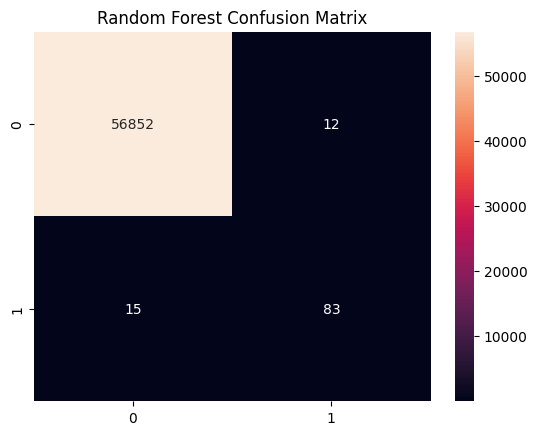

In [27]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

### Insight

The **Random Forest confusion matrix** shows that the model correctly classified **56,852 normal transactions**, while incorrectly flagging **12 normal transactions as fraud**. For fraudulent transactions, the model successfully detected **83 fraud cases** and missed **15 fraud transactions**.

This demonstrates a **significant improvement compared to the Logistic Regression model**, as the Random Forest model detects a **larger proportion of fraudulent transactions** while maintaining **very high overall accuracy**.

## 25. FEATURE IMPORTANCE

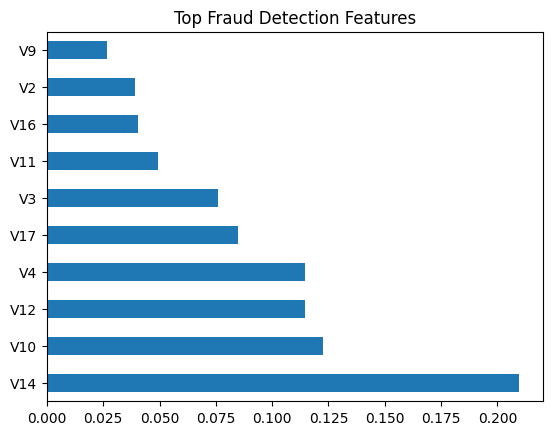

In [28]:
importances = rf_model.feature_importances_

feature_names = X.columns

feature_importance = pd.Series(importances, index=feature_names)

feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top Fraud Detection Features")
plt.show()

### Insight

The **feature importance analysis** identifies the variables that contribute most to fraud detection. The Random Forest model indicates that features such as **V14, V10, V12, V4, and V17** play a major role in distinguishing **fraudulent transactions from normal transactions**.

These features capture important **transaction patterns** that help the model identify suspicious activities. Understanding feature importance also improves **model interpretability** by highlighting which transaction characteristics are most influential in detecting fraud.

## 26. ROC CURVES

In [29]:
#IMPORT ROC TOOLS
from sklearn.metrics import roc_curve, roc_auc_score

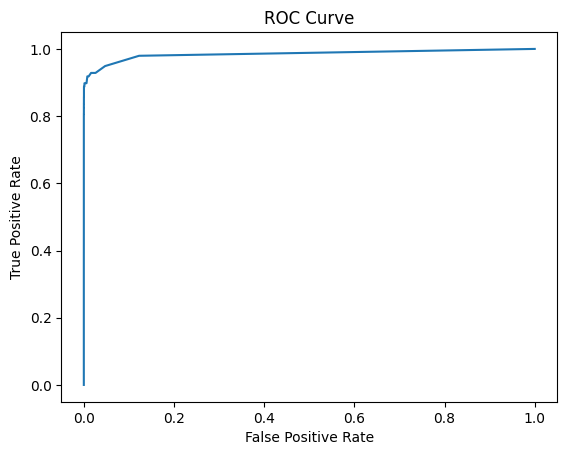

In [30]:
#COMPUTE ROC
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### Insight

The **ROC curve** evaluates the model’s ability to distinguish between **fraudulent and normal transactions**. The curve lies very close to the **top-left corner**, indicating **strong classification performance**. This suggests that the **Random Forest model** can effectively identify fraudulent transactions while maintaining a **low false positive rate**.

## 27. CALCULATE AUC SCORE

In [31]:
roc_auc_score(y_test, y_prob)

np.float64(0.9848788875426366)

### Insight

The **ROC AUC score of 0.98** indicates that the **Random Forest model** has **excellent discriminative ability** in distinguishing **fraudulent transactions from normal transactions**. A value close to **1.0** suggests that the model performs **very well in identifying fraud** while maintaining a **low false positive rate**.

## 28. MODEL COMPARISON

In [32]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.9991046662687406
Random Forest Accuracy: 0.9995259997893332


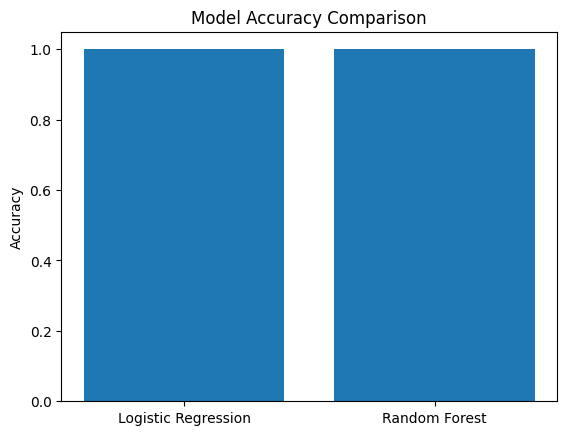

In [33]:
models = ['Logistic Regression', 'Random Forest']
scores = [lr_accuracy, rf_accuracy]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

### Insight

The **model comparison** shows that both **Logistic Regression** and **Random Forest** achieve very high accuracy due to the large number of **normal transactions** in the dataset. Logistic Regression achieved an accuracy of approximately **99.91%**, while **Random Forest** achieved a slightly higher accuracy of **99.95%**.

More importantly, Random Forest significantly improves **fraud detection performance**, identifying a **higher proportion of fraudulent transactions** compared to Logistic Regression. In highly imbalanced datasets like this one, **accuracy alone is not sufficient** to evaluate model performance. Metrics such as **recall for the fraud class** and the **ROC AUC score** provide a more meaningful assessment of a model’s ability to detect fraudulent activities.

## 29.FRAUD TRANSACTION ANALYSIS

In [34]:
fraud_transactions = df[df['Class'] == 1]

fraud_transactions[['Amount']].describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


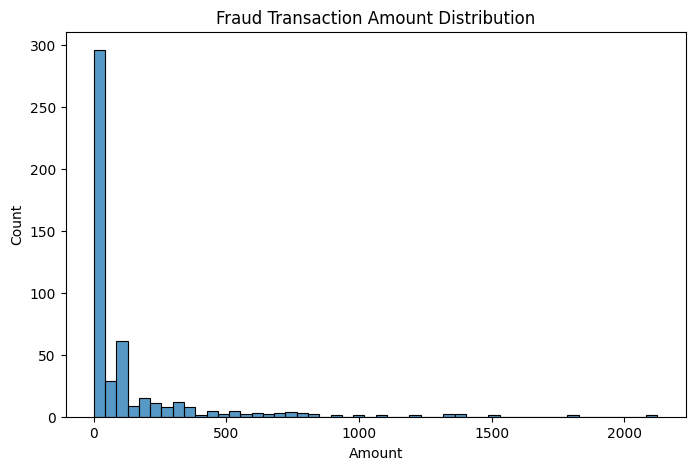

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(fraud_transactions['Amount'], bins=50)

plt.title("Fraud Transaction Amount Distribution")

plt.show()

### Insight

The distribution of **fraudulent transaction amounts** shows that most fraud cases occur at **relatively small transaction values**, while only a few involve **high-value transactions**. This pattern suggests that fraudulent activities often involve **smaller transactions**, possibly to **avoid detection by traditional monitoring systems**.

## 30. TOP SUSPICIOUS TRANSACTIONS

In [36]:
top_fraud = fraud_transactions.sort_values(by='Amount', ascending=False)

top_fraud[['Time','Amount']].head(10)

,Time,Amount
176049,122608.0,2125.87
6971,9064.0,1809.68
249167,154278.0,1504.93
89190,62467.0,1402.16
81609,59011.0,1389.56
95597,65385.0,1354.25
199896,133184.0,1335.00
10690,18088.0,1218.89
249239,154309.0,1096.99
233258,147501.0,996.27


### Insight

The **top suspicious transactions analysis** highlights the largest fraudulent transactions in the dataset. The **highest fraud transaction amount is approximately 2125.87**, with several other fraud transactions exceeding **1000**.

Identifying **high-value fraudulent transactions** is important because these cases often represent **significant financial risk** and require immediate investigation. Analyzing such transactions helps organizations **prioritize fraud monitoring** and strengthen their **risk management strategies**.

## 31. CONCLUSION

This project analyzed a **credit card transaction dataset containing 284,807 transactions**, where only **492 transactions (0.17%)** were fraudulent, making the dataset **highly imbalanced**. Initial analysis showed that fraudulent transactions represent a very small portion of the data, making fraud detection a challenging classification problem.

A **Logistic Regression model** was first implemented as a baseline model. While it achieved high overall accuracy due to the large number of normal transactions, its ability to detect fraud was limited, identifying only **57% of fraudulent transactions**.

To address the severe class imbalance, **SMOTE (Synthetic Minority Oversampling Technique)** was applied to balance the training dataset. After balancing the data, a **Random Forest classifier** was trained to improve fraud detection performance.

The Random Forest model significantly improved the results, achieving:

- **Accuracy:** ~99.95%  
- **Fraud Detection Recall:** ~85%  
- **ROC AUC Score:** ~0.98  

The confusion matrix showed that the model correctly identified **83 fraudulent transactions** while missing only **15**, demonstrating a strong ability to detect fraudulent activities while maintaining a **low false positive rate**.

Feature importance analysis revealed that variables such as **V14, V10, V12, V4, and V17** played a key role in identifying fraudulent patterns. Additionally, analysis of transaction amounts showed that most fraud transactions occurred at **relatively small values**, though some **high-value suspicious transactions** were also detected.

Overall, this project demonstrates that combining **data preprocessing**, **class imbalance handling**, and **ensemble machine learning models** can significantly improve fraud detection systems. Such approaches can help financial institutions **detect suspicious activities more effectively** and **reduce financial losses caused by fraudulent transactions**.